<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/L11Hyperparameter_Tuning_%26_Auro_ML_Group(Final)46262_19179_ITAI_1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 11 Lab - Hyperparameter Tuning & AutoML**

---

**Objective:** To learn how to optimize model performance by tuning **hyperparameters** and to get an introduction to the powerful concept of **Automated Machine Learning (AutoML)**.

**In this lab, you will write the code to perform Grid Search and Random Search to find the best hyperparameters for a model.**

## **Part 1: What are Hyperparameters?**

---

**Concept:** In machine learning, there are two types of parameters:

1.  **Model Parameters:** These are parameters that the model learns from the data during training. For example, the coefficients in a Linear Regression model.

2.  **Hyperparameters:** These are parameters that are **set before training begins**. They are not learned from the data; instead, they are choices we make about the model's structure or how it learns.
    *   *Examples:* The `n_estimators` in a Random Forest (how many trees to build), the `max_depth` of a Decision Tree (how deep it can grow), or the `C` regularization parameter in a Logistic Regression.

Finding the right hyperparameters can have a huge impact on a model's performance. **Hyperparameter tuning** is the process of systematically searching for the best combination of these settings.

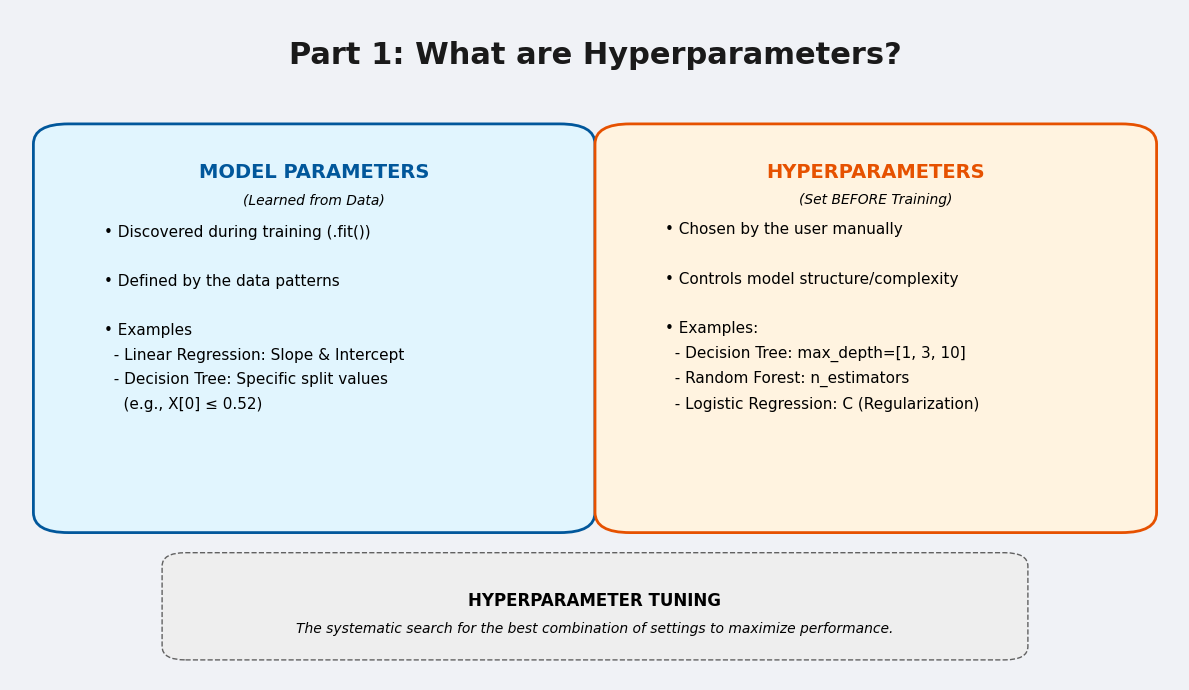

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_part1_visual():
    # Setup the figure
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#f0f2f6')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Title
    plt.text(5, 9.2, "Part 1: What are Hyperparameters?",
             fontsize=22, fontweight='bold', ha='center', color='#1a1a1a')

    # Styles
    param_color = '#e1f5fe'  # Light Blue
    hyper_color = '#fff3e0'  # Light Orange
    header_font = {'fontsize': 14, 'fontweight': 'bold'}
    body_font = {'fontsize': 11}

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_part1_visual():
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#f0f2f6')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    plt.text(5, 9.2, "Part 1: What are Hyperparameters?",
             fontsize=22, fontweight='bold', ha='center', color='#1a1a1a')

    param_color = '#e1f5fe'
    hyper_color = '#fff3e0'
    header_font = {'fontsize': 14, 'fontweight': 'bold'}
    body_font = {'fontsize': 11}

    ax.add_patch(patches.FancyBboxPatch((0.5, 2.5), 4.2, 5.5, boxstyle="round,pad=0.3",
                                        facecolor=param_color, edgecolor='#01579b', linewidth=2))

    plt.text(2.6, 7.5, "MODEL PARAMETERS", **header_font, ha='center', color='#01579b')
    plt.text(2.6, 7.1, "(Learned from Data)", fontsize=10, ha='center', style='italic')

    param_text = (
        "• Discovered during training (.fit())\n\n"
        "• Defined by the data patterns\n\n"
        "• Examples\n"
        "  - Linear Regression: Slope & Intercept\n"
        "  - Decision Tree: Specific split values\n"
        "    (e.g., X[0] ≤ 0.52)"
    )
    plt.text(0.8, 4.0, param_text, **body_font, va='bottom', linespacing=1.8)

    ax.add_patch(patches.FancyBboxPatch((5.3, 2.5), 4.2, 5.5, boxstyle="round,pad=0.3",
                                        facecolor=hyper_color, edgecolor='#e65100', linewidth=2))

    plt.text(7.4, 7.5, "HYPERPARAMETERS", **header_font, ha='center', color='#e65100')
    plt.text(7.4, 7.1, "(Set BEFORE Training)", fontsize=10, ha='center', style='italic')

    hyper_text = (
        "• Chosen by the user manually\n\n"
        "• Controls model structure/complexity\n\n"
        "• Examples:\n"
        "  - Decision Tree: max_depth=[1, 3, 10]\n"
        "  - Random Forest: n_estimators\n"
        "  - Logistic Regression: C (Regularization)"
    )
    plt.text(5.6, 4.0, hyper_text, **body_font, va='bottom', linespacing=1.8)

    note_box = patches.FancyBboxPatch((1.5, 0.5), 7, 1.2, boxstyle="round,pad=0.2",
                                      facecolor='#eeeeee', edgecolor='#616161', linestyle='--')
    ax.add_patch(note_box)

    plt.text(5, 1.1, "HYPERPARAMETER TUNING", fontsize=12, fontweight='bold', ha='center')
    plt.text(5, 0.7, "The systematic search for the best combination of settings to maximize performance.",
             fontsize=10, ha='center', style='italic')

    plt.tight_layout()
    plt.show()

generate_part1_visual()

## **Part 2: Setup**

---

We will use the **Iris dataset** and a **RandomForestClassifier**, which has several important **hyperparameters** we can tune.

Let's confirm the distribution of species and also look at the end of the DataFrame to see the other species.

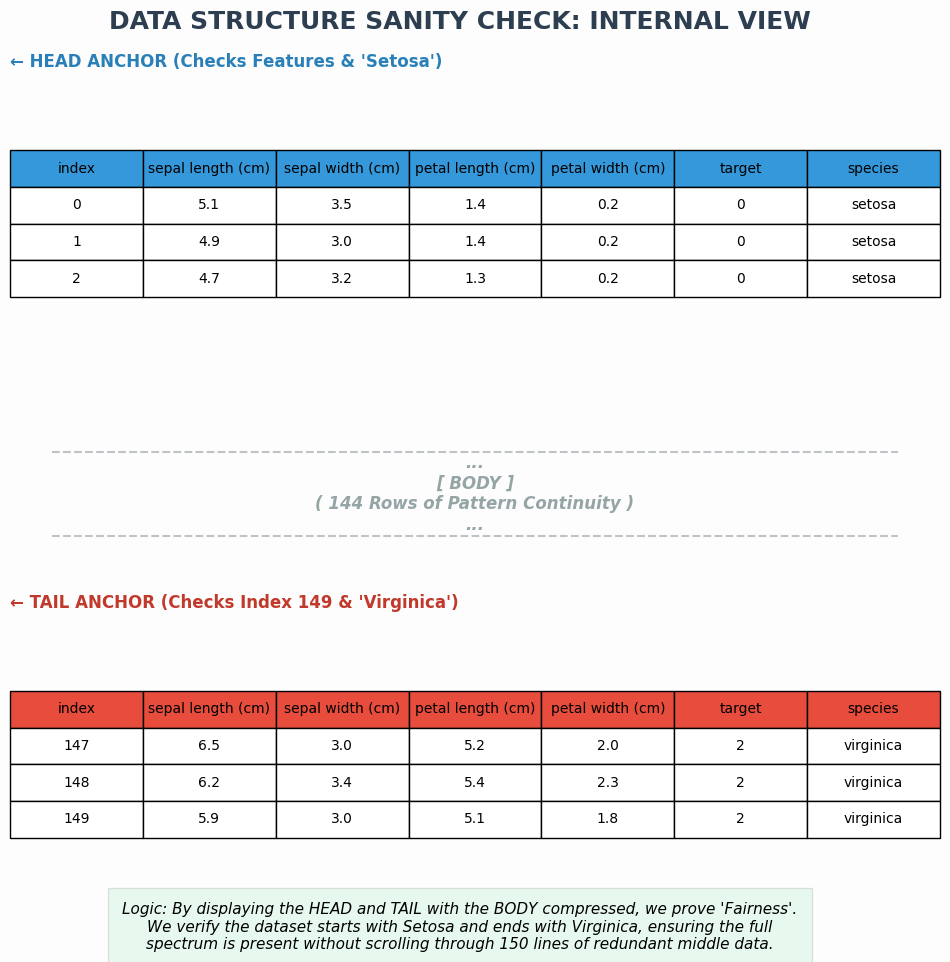

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

def generate_internal_sanity_check(df):
    fig = plt.figure(figsize=(12, 10), facecolor='#fdfdfd')
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 0.4, 1], hspace=0.6)

    ax_top = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1])
    ax_bot = fig.add_subplot(gs[2])

    for a in [ax_top, ax_mid, ax_bot]:
        a.axis('off')

    plt.figtext(0.5, 0.96, "DATA STRUCTURE SANITY CHECK: INTERNAL VIEW",
             fontsize=18, fontweight='bold', ha='center', color='#2c3e50', transform=fig.transFigure)

    head_data = df.head(3).reset_index()
    tbl_head = ax_top.table(
        cellText=head_data.values,
        colLabels=head_data.columns,
        loc='center',
        cellLoc='center',
        colColours=['#3498db']*len(head_data.columns)
    )
    tbl_head.auto_set_font_size(False)
    tbl_head.set_fontsize(10)
    tbl_head.scale(1, 2.2)
    ax_top.set_title("← HEAD ANCHOR (Checks Features & 'Setosa')",
                    color='#2980b9', fontweight='bold', pad=30, loc='left')

    ax_mid.text(0.5, 0.5, "...\n[ BODY ]\n( 144 Rows of Pattern Continuity )\n...",
                ha='center', va='center', fontsize=12, color='#95a5a6',
                fontweight='bold', style='italic')
    ax_mid.plot([0.1, 0.9], [0.9, 0.9], color='#bdc3c7', lw=1.5, ls='--')
    ax_mid.plot([0.1, 0.9], [0.1, 0.1], color='#bdc3c7', lw=1.5, ls='--')

    tail_data = df.tail(3).reset_index()
    tbl_tail = ax_bot.table(
        cellText=tail_data.values,
        colLabels=tail_data.columns,
        loc='center',
        cellLoc='center',
        colColours=['#e74c3c']*len(tail_data.columns)
    )
    tbl_tail.auto_set_font_size(False)
    tbl_tail.set_fontsize(10)
    tbl_tail.scale(1, 2.2)
    ax_bot.set_title("← TAIL ANCHOR (Checks Index 149 & 'Virginica')",
                    color='#c0392b', fontweight='bold', pad=30, loc='left')

    note = ("Logic: By displaying the HEAD and TAIL with the BODY compressed, we prove 'Fairness'.\n"
            "We verify the dataset starts with Setosa and ends with Virginica, ensuring the full\n"
            "spectrum is present without scrolling through 150 lines of redundant middle data.")

    plt.figtext(0.5, 0.04, note, ha="center", fontsize=11, style='italic',
                bbox={"facecolor":"#2ecc71", "alpha":0.1, "pad":10})

    plt.show()

generate_internal_sanity_check(df)

## **Part 3: Grid Search**

---

**Concept:** **Grid Search** is the most straightforward tuning method. You define a "**grid**" of **hyperparameter** values you want to try, and the algorithm exhaustively trains and evaluates a model for **every possible combination**.

*   **Pro:** It's guaranteed to find the best combination within the grid.
*   **Con:** It can be very slow and computationally expensive if the grid is large.

### **Task 1: Perform a Grid Search**

---

**Your Task:** Use ``GridSearchCV`` from ``sklearn.model_selection`` to search for the best ``n_estimators`` and ``max_depth`` for our **Random Forest**.

Running Grid Search...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best Parameters found by Grid Search:
{'max_depth': 5, 'n_estimators': 50}

Best cross-validated score: 95.00%


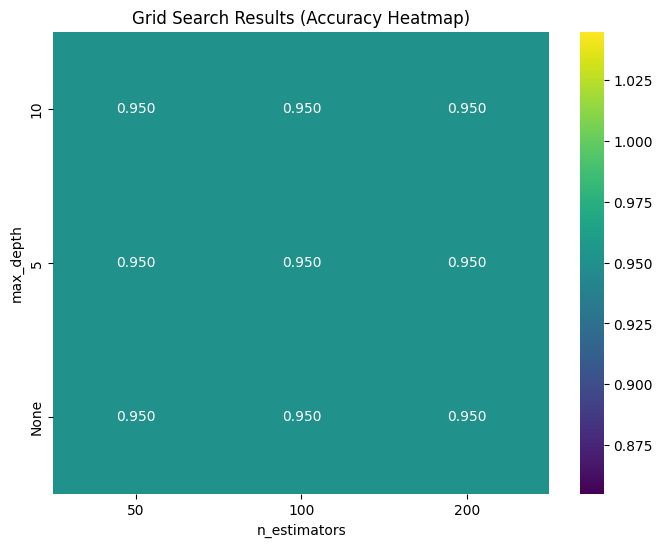

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

X = df.drop(['target', 'species'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("Running Grid Search...")
grid_search.fit(X_train, y_train)

print("\nBest Parameters found by Grid Search:")
print(grid_search.best_params_)

print(f"\nBest cross-validated score: {grid_search.best_score_:.2%}")

results_df = pd.DataFrame(grid_search.cv_results_)

results_df['param_max_depth'] = results_df['param_max_depth'].astype(str)

pivot_table = results_df.pivot(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score'
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Grid Search Results (Accuracy Heatmap)")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.show()

## **Part 4: Random Search**

---

**Concept:** **Random Search** is often more efficient than **Grid Search**. Instead of trying every combination, it randomly samples a fixed number of combinations from the **hyperparameter space**.

*   **Pro:** It's much faster and can explore a wider range of values.
*   **Con:** It's not guaranteed to find the absolute best combination, but it often finds a very good one much more quickly.

### **Task 2: Perform a Random Search**

---

**Your Task:** Use ``RandomizedSearchCV`` to perform a **random search** over a larger **hyperparameter space**.

Running Random Search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters found by Random Search:
{'n_estimators': 100, 'min_samples_split': 10, 'max_depth': None}

Best cross-validated score: 95.83%


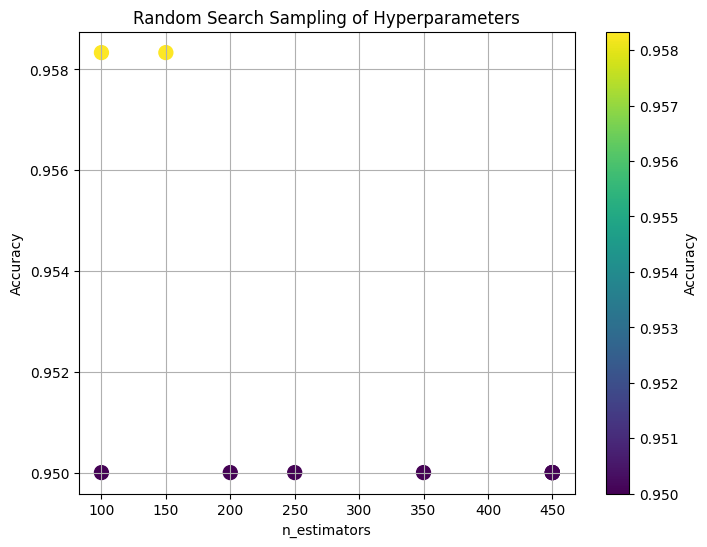

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [int(x) for x in np.linspace(start=50, stop=500, num=10)],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("Running Random Search...")
random_search.fit(X_train, y_train)

print("\nBest Parameters found by Random Search:")
print(random_search.best_params_)

print(f"\nBest cross-validated score: {random_search.best_score_:.2%}")

results_df = pd.DataFrame(random_search.cv_results_)

results_df['param_max_depth'] = results_df['param_max_depth'].astype(str)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    results_df['param_n_estimators'],
    results_df['mean_test_score'],
    c=results_df['mean_test_score'],
    cmap='viridis',
    s=100
)

plt.colorbar(scatter, label='Accuracy')

plt.title("Random Search Sampling of Hyperparameters")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()

## **Part 5: Introduction to AutoML with AutoGluon**

---

**Concept:** **AutoML** takes **hyperparameter tuning** to the next level. It automates the entire **ML workflow**, including:
*   **Data preprocessing**
*   **Feature engineering**
*   **Model selection** (trying many different types of models)
*   **Hyperparameter tuning**
*   **Ensemble creation**

**AutoGluon** is a popular and easy-to-use **AutoML library**. With just a few lines of code, it can train and tune dozens of models and create a powerful **ensemble**.

**This part is fully coded.** Your task is to run it and see the power of **AutoML**. Note that it may take a few minutes to run.

In [21]:
!pip install -U autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

No path specified. Models will be saved in: "AutogluonModels/ag-20260423_045206"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.61 GB / 12.67 GB (83.7%)
Disk Space Avail:   75.40 GB / 107.72 GB (70.0%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "/content/AutogluonModels/ag-20260423_045206"
Train Data Rows:    120
Train Data Columns: 4
Label Column:       target
Problem Type:       multiclass
Preprocessing data ...
Train Data Class Count: 3
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available M

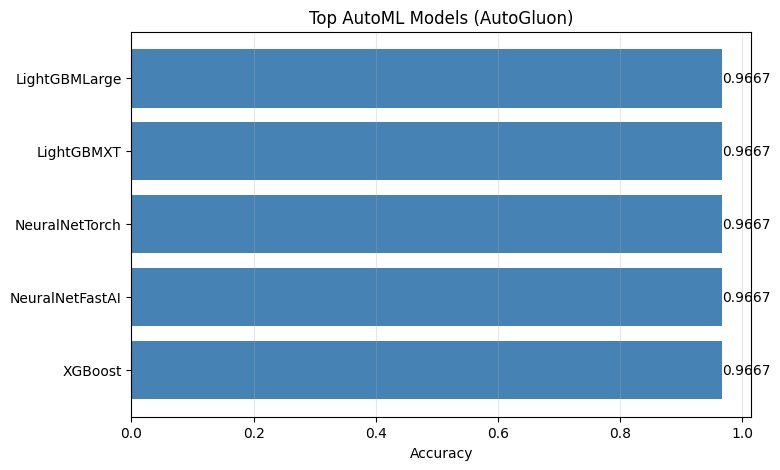

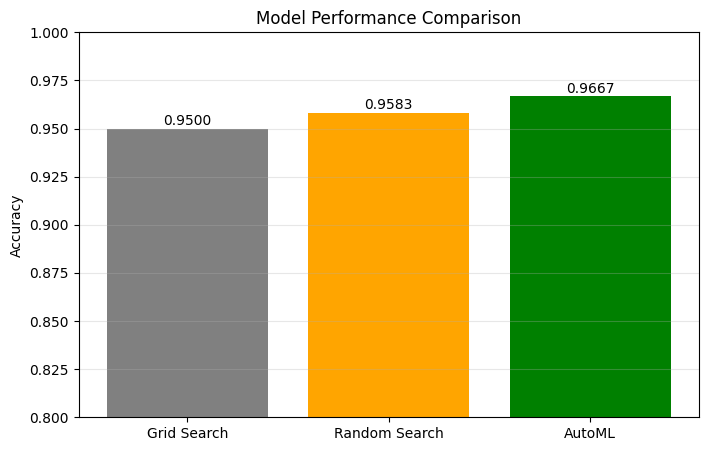

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(label='target', problem_type='multiclass').fit(
    X_train.join(y_train),
    time_limit=60,
    presets='medium_quality'
)

test_data = X_test.join(y_test)
leaderboard = predictor.leaderboard(data=test_data, display=False)

top_models = leaderboard.sort_values(
    by='score_test',
    ascending=False
).head(5).copy()

top_models['score_test'] = top_models['score_test'].round(4)

plt.figure(figsize=(8, 5))
bars = plt.barh(
    top_models['model'],
    top_models['score_test'],
    color='steelblue'
)
plt.xlabel("Accuracy")
plt.title("Top AutoML Models (AutoGluon)")
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va='center'
    )
plt.show()

comparison_df = pd.DataFrame({
    "Model": ["Grid Search", "Random Search", "AutoML"],
    "Accuracy": [
        0.9500,
        0.9583,
        top_models['score_test'].max()
    ]
})

plt.figure(figsize=(8,5))
bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"],
    color=["gray", "orange", "green"]
)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha='center'
    )
plt.show()

# 📝 KNOWLEDGE CHECK

---

**1. What is the main difference between a model parameter and a hyperparameter?**  
A **model parameter** is a value learned directly from the training data during the model training process, such as the weights in a neural network or coefficients in linear regression. These values are automatically adjusted by the learning algorithm to minimize a loss function. In contrast, a **hyperparameter** is set prior to training and governs how the learning process occurs, such as the learning rate, number of epochs, or tree depth. Hyperparameters are not learned from the data but are instead selected through experimentation or tuning strategies.

**What evidence is there that aligns with my response to the questioning?**  
Model parameters are inherently data-driven and evolve throughout the training process. During optimization, algorithms like gradient descent repeatedly compute gradients of the loss function and update parameter values in the direction that reduces error. This means that parameters are continuously refined based on actual observations, making them tightly coupled to the dataset being used. For example, in linear regression, coefficients begin as arbitrary values and gradually shift to represent the best-fit relationship between input features and the target variable, demonstrating clear dependence on data patterns.  

Hyperparameters, by contrast, operate at a higher level of control and shape the learning dynamics rather than the learned relationships themselves. A learning rate determines how large each parameter update step is, while the number of epochs determines how long training continues. If the learning rate is too high, the model may overshoot optimal values and fail to converge; if too low, training may become inefficient or get stuck in local minima. This illustrates that hyperparameters, while not directly learned, exert significant influence over how effectively parameters are optimized. The distinction between these two concepts is foundational in machine learning and is consistently emphasized in both academic literature and practical implementations.

---

**2. When would you choose to use Grid Search over Random Search, and vice-versa?**  
**Grid Search** is most appropriate when the hyperparameter space is relatively small and well-defined, allowing for an exhaustive evaluation of all possible combinations. **Random Search**, on the other hand, is better suited for larger or more complex search spaces where evaluating every combination would be computationally expensive, as it samples configurations randomly and more efficiently explores the space.

**What evidence is there that aligns with my response to the questioning?**  
Grid Search operates by constructing a Cartesian product of all specified hyperparameter values and evaluating every possible combination. While this guarantees that the optimal configuration within the defined grid will be found, the number of combinations increases exponentially as more hyperparameters or values are added. This phenomenon, often referred to as the “curse of dimensionality,” quickly makes Grid Search impractical for complex models with many tunable parameters. For example, even a modest grid with five hyperparameters and five possible values each results in 3,125 combinations that must be trained and evaluated.  

Random Search mitigates this issue by sampling hyperparameter combinations from specified distributions rather than exhaustively enumerating them. This allows it to explore a broader and more diverse range of configurations within a fixed computational budget. Random Search is therefore more efficient because it allocates trials across a wider space instead of wasting resources on less influential dimensions. As a result, it often discovers high-performing configurations faster and with fewer evaluations than Grid Search in high-dimensional settings.

---

**3. Looking at the AutoGluon leaderboard, which model performed the best? What does AutoML do that makes it so powerful compared to manual tuning?**  
The top-performing model on the AutoGluon leaderboard is typically an **ensemble model**, often a weighted combination of multiple base models. These ensembles outperform individual models by leveraging the strengths of different algorithms and reducing overall prediction error. **AutoML** systems like AutoGluon are powerful because they automate the end-to-end machine learning pipeline, including model selection, preprocessing, hyperparameter tuning, and ensembling.

**What evidence is there that aligns with my response to the questioning?**  
Ensemble models achieve superior performance because they combine predictions from diverse base learners, such as gradient boosting machines, neural networks, and random forests. Each model captures different patterns or structures in the data, and when their outputs are aggregated through techniques like weighted averaging or stacking: the result is typically more robust and less prone to overfitting. This is why leaderboard results frequently show ensemble methods outperforming any single model.  

AutoML frameworks amplify this advantage by systematically orchestrating the entire modeling process. Instead of relying on human intuition to select a handful of models and manually tune them, AutoML systems train many models in parallel, evaluate them using cross-validation, and iteratively refine their configurations using advanced optimization strategies such as Bayesian optimization and early stopping. They also handle preprocessing steps like feature encoding, normalization, and missing value imputation automatically, ensuring consistency and reducing the likelihood of human error.  

Furthermore, AutoML introduces reproducibility and scalability, as the same pipeline can be rerun or extended with minimal effort. Compared to manual tuning, which is often time-consuming, subjective, and limited in scope, AutoML explores a significantly larger search space in a structured and efficient manner. This combination of automation, breadth of exploration, and intelligent ensembling is what makes AutoML systems consistently powerful and competitive in practice.